
### Course
Deep Learning Architectures and Techniques (ETMMDL274)

### Assignment
Lab Assignment 1

### Student Name
Shubham Goel

### Roll Number
2501940014

### Instructor
Dr. Shahid Ahmad Wani

---

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

# Fix random seed (important for reproducibility)
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9933s 58us/step  


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [6]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train)

In [7]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 125ms/step - accuracy: 0.3296 - loss: 1.7963 - val_accuracy: 0.4824 - val_loss: 1.4204
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.4342 - loss: 1.5417 - val_accuracy: 0.5148 - val_loss: 1.3327
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - accuracy: 0.4897 - loss: 1.4190 - val_accuracy: 0.5638 - val_loss: 1.2160
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - accuracy: 0.5172 - loss: 1.3469 - val_accuracy: 0.5922 - val_loss: 1.1320
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.5386 - loss: 1.2858 - val_accuracy: 0.6015 - val_loss: 1.1053
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.5568 - loss: 1.2425 - val_accuracy: 0.6391 - val_loss: 1.0219
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.5756 - loss: 1.1897 - val_accuracy: 0.6402 - val_loss: 1.0021
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.5871 - loss: 1

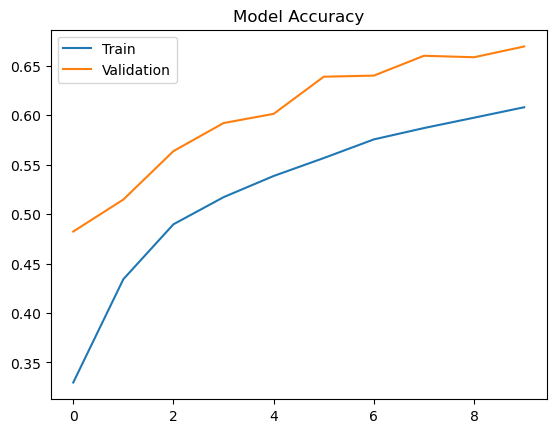

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [11]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      1000
           1       0.69      0.88      0.77      1000
           2       0.81      0.34      0.48      1000
           3       0.48      0.51      0.49      1000
           4       0.66      0.57      0.61      1000
           5       0.60      0.57      0.59      1000
           6       0.67      0.82      0.73      1000
           7       0.63      0.82      0.71      1000
           8       0.89      0.68      0.77      1000
           9       0.68      0.82      0.75      1000

    accuracy                           0.67     10000
   macro avg       0.69      0.67      0.66     10000
weighted avg       0.69      0.67      0.66     10000



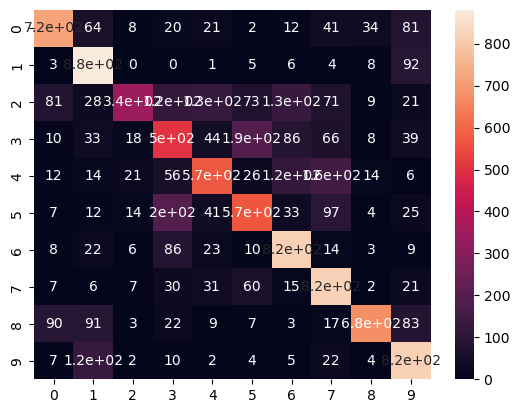

In [12]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True)
plt.show()

In [13]:
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(preprocess)
    .batch(BATCH_SIZE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(preprocess)
    .batch(BATCH_SIZE)
)

In [14]:
import numpy as np
import tensorflow as tf

num_classes = len(np.unique(y_train))

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [16]:
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [17]:
model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)

Epoch 1/5
  57/1250 ━━━━━━━━━━━━━━━━━━━━ 20:53 1s/step - accuracy: 0.0816 - loss: 2.4183    

In [ ]:
y_pred = model_tl.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

# If one-hot encoded labels
if len(y_true.shape) > 1:
    y_true = np.argmax(y_true, axis=1)

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_classes))